# 1. Data Preparation
## 1.1 Load the Data
Load the synthetic data (e.g., NLS_Group03.txt) and split it into two or three classes based on the file's structure.

In [76]:
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

# Assuming the first line is a header and skipping it
lines = lines[1:]

# Split data into classes (example: first 2447 lines belong to Class 1, and the rest to Class 2)
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line)
    else:  # Class 2
        class2_data.append(line)


## 1.2 Clean the Data
Convert the data from strings to numeric arrays using numpy

In [77]:
import numpy as np

def clean_data(data):
    cleaned = []
    for row in data:
        cleaned_row = list(map(float, row.strip().split()))
        cleaned.append(cleaned_row)
    return np.array(cleaned)

class1_np = clean_data(class1_data)
class2_np = clean_data(class2_data)


## Mean and Standard Deviation for each classes

In [99]:
# Example analysis: Compute mean and standard deviation for each class
class1_mean = np.mean(class1_np, axis=0)
class1_std = np.std(class1_np, axis=0)
class2_mean = np.mean(class2_np, axis=0)
class2_std = np.std(class2_np, axis=0)

print("\nClass 1 Mean:", class1_mean)
print("Class 1 Standard Deviation:", class1_std)
print("\nClass 2 Mean:", class2_mean)
print("Class 2 Standard Deviation:", class2_std)


Class 1 Mean: [ 0.10919244 -1.04641247]
Class 1 Standard Deviation: [5.61276654 5.49292049]

Class 2 Mean: [1.02018638 2.06096327]
Class 2 Standard Deviation: [5.57550581 5.45448295]


## 1.3 Combine Data and Create Labels
Combine the data for both classes and create labels (0 for Class 1 and 1 for Class 2).

In [78]:
X = np.vstack((class1_np, class2_np))  # Combine features from both classes
y = np.hstack((np.zeros(len(class1_np)), np.ones(len(class2_np))))  # Labels: 0 for Class 1, 1 for Class 2


In [79]:
X,y

(array([[ 1.006419,  7.971535],
        [-8.568597, -0.994905],
        [-7.830411, -6.082278],
        ...,
        [ 7.845237,  8.196611],
        [-2.968971, -6.084928],
        [-1.417023,  5.735476]]),
 array([0., 0., 0., ..., 1., 1., 1.]))

## 1.4 Data Normalization
Normalize the features to ensure all features have equal contributions.

In [80]:
# def normalize(X):
#     return (X - X.mean(axis=0)) / X.std(axis=0)

# X = normalize(X)


## 1.5 Manual Train-Test Split
Split the data into 70% training and 30% testing manually

In [81]:
def train_test_split_manual(X, y, test_size=0.3):
    n_samples = X.shape[0]
    n_train = int(n_samples * (1 - test_size))
    
    # Shuffle the data
    indices = np.random.permutation(n_samples)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # Split the data
    X_train, X_test = X_shuffled[:n_train], X_shuffled[n_train:]
    y_train, y_test = y_shuffled[:n_train], y_shuffled[n_train:]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_manual(X, y)


# 2. K-Means for GMM Initialization
## 2.1 K-Means Clustering (from Scratch)
Implement K-means to initialize the GMM parameters.

In [82]:
def kmeans(X, k, max_iters=100):
    # Randomly initialize centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Step 1: Assign points to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # Euclidean distance
        labels = np.argmin(distances, axis=1)

        # Step 2: Recompute centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # Check for convergence
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return centroids, labels


# 3. Implementing Gaussian Mixture Model (GMM) Using EM Algorithm
## 3.1 GMM Initialization Using K-Means
Use K-means clustering to initialize the means for the GMM.
Initialize the weights (proportions) and covariances for the Gaussians.

In [83]:
def gmm_initialize(X, k):
    centroids, labels = kmeans(X, k)
    weights = np.array([np.mean(labels == i) for i in range(k)])
    covariances = np.array([np.cov(X[labels == i].T) for i in range(k)])
    return centroids, covariances, weights


## 3.2 Gaussian PDF Calculation
Implement the Gaussian probability density function (PDF).

In [84]:
def gaussian_pdf(X, mean, cov):
    n = X.shape[1]
    diff = X - mean
    exp_term = np.exp(-0.5 * np.sum(np.dot(diff, np.linalg.inv(cov)) * diff, axis=1))
    return exp_term / np.sqrt((2 * np.pi)**n * np.linalg.det(cov))


## 3.3 Expectation-Maximization (EM) Algorithm for GMM
Implement the EM algorithm to fit a GMM to the data.

In [85]:
import numpy as np

def multivariate_gaussian(x, mean, cov):
    """Computes the multivariate Gaussian probability density function."""
    n = len(mean)
    diff = x - mean
    exp_term = np.exp(-0.5 * np.dot(diff.T, np.dot(np.linalg.inv(cov), diff)))
    return exp_term / np.sqrt((2 * np.pi) ** n * np.linalg.det(cov))

def gmm_em(X, k, max_iters=100, tol=1e-4):
    """
    GMM-EM algorithm to fit a Gaussian Mixture Model.

    Parameters:
    X: Data points (n_samples, n_features)
    k: Number of mixture components
    max_iters: Maximum number of iterations
    tol: Convergence tolerance for log-likelihood

    Returns:
    means: Array of shape (k, n_features) containing the means of the Gaussians
    covariances: Array of shape (k, n_features, n_features) containing the covariance matrices
    weights: Array of shape (k,) containing the mixture weights
    log_likelihoods: List containing the log-likelihood at each iteration
    """
    n_samples, n_features = X.shape

    # Initialize parameters
    np.random.seed(0)
    means = X[np.random.choice(n_samples, k, replace=False)]  # Randomly choose k data points as initial means
    covariances = [np.cov(X.T) for _ in range(k)]  # Initialize covariance matrices as the identity matrix
    weights = np.ones(k) / k  # Equal weights for each component initially

    log_likelihoods = []  # To store the log-likelihood values for each iteration

    for iteration in range(max_iters):
        # E-step: Compute responsibilities (posterior probabilities)
        responsibilities = np.zeros((n_samples, k))

        for i in range(k):
            for j in range(n_samples):
                responsibilities[j, i] = weights[i] * multivariate_gaussian(X[j], means[i], covariances[i])

        # Normalize responsibilities across components for each data point
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step: Update parameters (means, covariances, and weights)
        Nk = responsibilities.sum(axis=0)  # Effective number of data points assigned to each component

        for i in range(k):
            means[i] = np.sum(responsibilities[:, i][:, np.newaxis] * X, axis=0) / Nk[i]
            diff = X - means[i]
            covariances[i] = np.dot((responsibilities[:, i][:, np.newaxis] * diff).T, diff) / Nk[i]
            weights[i] = Nk[i] / n_samples

        # Compute log-likelihood for the current iteration
        log_likelihood = 0.0
        for j in range(n_samples):
            prob_sum = 0
            for i in range(k):
                prob_sum += weights[i] * multivariate_gaussian(X[j], means[i], covariances[i])
            log_likelihood += np.log(prob_sum)

        log_likelihoods.append(log_likelihood)

        # Check for convergence
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            print(f'Convergence reached at iteration {iteration}')
            break

    return means, covariances, weights, log_likelihoods


# 4. GMM-Based Bayes Classifier
## 4.1 Train a GMM for Each Class
Train a GMM for each class using the EM algorithm.

Convergence reached at iteration 72


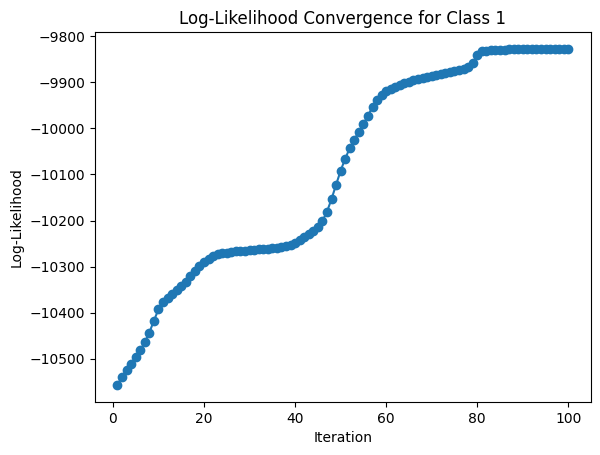

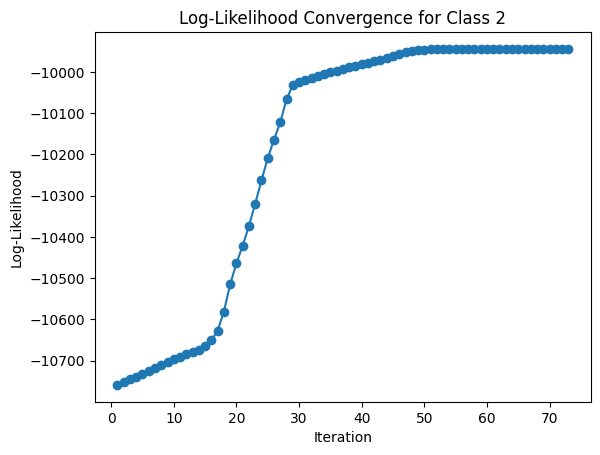

In [86]:
# Separate data by class
X_class1 = X_train[y_train == 0]
X_class2 = X_train[y_train == 1]

# Train GMM for Class 1 and Class 2 with k=4 components
means_class1, cov_class1, weights_class1, log_likelihoods_class1 = gmm_em(X_class1, k=4)
means_class2, cov_class2, weights_class2, log_likelihoods_class2 = gmm_em(X_class2, k=4)

# Plot log-likelihood for Class 1
plt.plot(range(1, len(log_likelihoods_class1) + 1), log_likelihoods_class1, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Convergence for Class 1')
plt.show()

# Plot log-likelihood for Class 2
plt.plot(range(1, len(log_likelihoods_class2) + 1), log_likelihoods_class2, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Convergence for Class 2')
plt.show()


## 4.2 Classify Test Data Using GMM and Bayes Rule
For each test point, calculate the log-likelihood for both classes and assign the class with the higher likelihood.

In [87]:
def gaussian_pdf(X, mean, cov):
    """Compute the probability density function of the multivariate Gaussian distribution."""
    n = len(mean)
    diff = X - mean
    exponent = np.exp(-0.5 * np.einsum('ij,ij->i', diff, np.dot(np.linalg.inv(cov), diff.T).T))
    return exponent / np.sqrt((2 * np.pi) ** n * np.linalg.det(cov))


In [88]:
def gmm_log_likelihood(X, means, covariances, weights):
    """
    Compute the log-likelihood for a set of data points X, given the GMM parameters.
    Uses the log-sum-exp trick for numerical stability.
    """
    log_likelihood = np.zeros(X.shape[0])
    for i in range(len(means)):
        log_likelihood += weights[i] * gaussian_pdf(X, means[i], covariances[i])
    
    # Apply log-sum-exp trick
    return np.log(log_likelihood + 1e-10)  # Small epsilon added to avoid log(0)


# Compute log-likelihood for each test point for both classes
log_prob_class1 = gmm_log_likelihood(X_test, means_class1, cov_class1, weights_class1)
log_prob_class2 = gmm_log_likelihood(X_test, means_class2, cov_class2, weights_class2)

# Assign class with higher log probability
y_pred = np.where(log_prob_class1 > log_prob_class2, 0, 1)



In [89]:
y_pred

array([1, 1, 1, ..., 0, 0, 0])

# 5. Performance Evaluation
## 5.1 Calculate Accuracy
Compute the classification accuracy by comparing the predicted labels (y_pred) with the true labels (y_test).

In [90]:
def accuracy_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

accuracy = accuracy_manual(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.9243869209809265


## 5.2 Precision, Recall, and F-measure (Manually)
Compute precision, recall, and F-measure for each class manually using the true positives (TP), false positives (FP), and false negatives (FN).

In [91]:
def precision_recall_f1(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1_score

precision, recall, f1_score = precision_recall_f1(y_test, y_pred)
print(f"Precision: {precision}, Recall: {recall}, F1-score: {f1_score}")


Precision: 0.9052069425901201, Recall: 0.9442896935933147, F1-score: 0.9243353783231084


# 6. Visualizations
## 6.1 Scatter Plot of Classes
Plot the training data with different colors for each class.

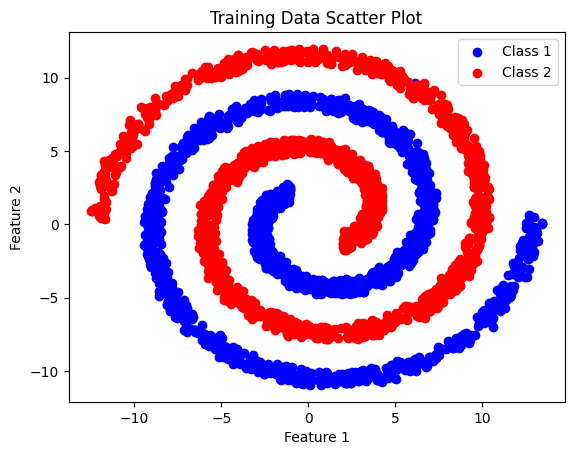

In [92]:
import matplotlib.pyplot as plt

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data Scatter Plot')
plt.legend()
plt.show()


## 6.2 Decision Region Plot
Create a plot that shows the decision boundaries between the two classes.

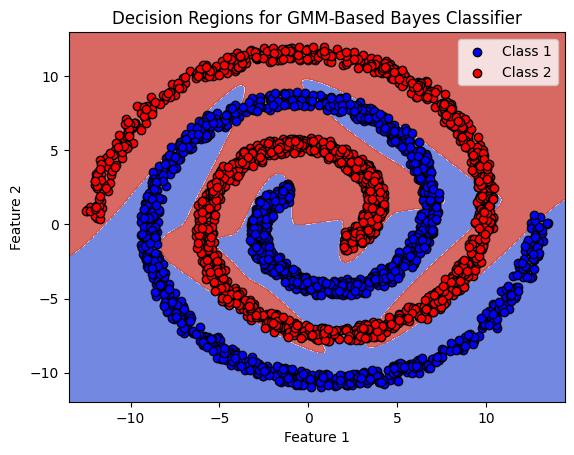

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a grid of points covering the feature space
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Stack the grid into a 2D array of points
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Step 2: Compute log-likelihood for each class
log_prob_class1 = gmm_log_likelihood(grid_points, means_class1, cov_class1, weights_class1)
log_prob_class2 = gmm_log_likelihood(grid_points, means_class2, cov_class2, weights_class2)

# Step 3: Assign class based on higher log-likelihood
Z = np.where(log_prob_class1 > log_prob_class2, 0, 1)

# Step 4: Reshape Z back to the shape of the grid
Z = Z.reshape(xx.shape)

# Step 5: Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')

# Step 6: Overlay the training data points
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', edgecolor='k', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', edgecolor='k', label='Class 2')

# Add labels, title, and legend
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions for GMM-Based Bayes Classifier')
plt.legend()
plt.show()


## Confusion Matrix:


In [94]:
# Assuming you have y_test and y_pred after classifying the test data using the custom GMM model
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy: ", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[679  71]
 [ 40 678]]
Accuracy:  0.9243869209809265


## Contour Plot of Constant Density:
This code generates a contour plot to visualize constant density regions for each class based on the GMM model's log-likelihood for different points in the feature space.

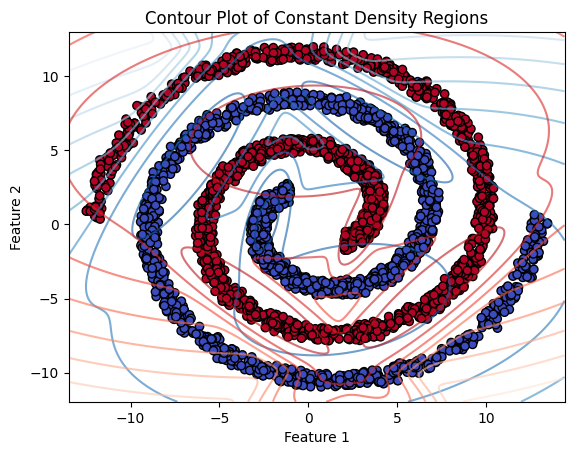

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming means_class1, cov_class1, and weights_class1 are already computed from your custom GMM
# and means_class2, cov_class2, and weights_class2 for the second class.

# Step 1: Create a grid of points covering the feature space
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

# Step 2: Evaluate log-likelihood for each class at the grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
log_prob_class1 = gmm_log_likelihood(grid_points, means_class1, cov_class1, weights_class1)
log_prob_class2 = gmm_log_likelihood(grid_points, means_class2, cov_class2, weights_class2)

# Step 3: Reshape the log-likelihood for contour plotting
log_prob_class1 = log_prob_class1.reshape(xx.shape)
log_prob_class2 = log_prob_class2.reshape(xx.shape)

# Step 4: Plot contour for each class
plt.contour(xx, yy, log_prob_class1, levels=10, cmap='Blues', alpha=0.6)
plt.contour(xx, yy, log_prob_class2, levels=10, cmap='Reds', alpha=0.6)

# Overlay the training data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k')
plt.title('Contour Plot of Constant Density Regions')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


## Decision Region Plot:
This code visualizes the decision boundary using your custom GMM implementation. It compares the log-likelihoods for each class and assigns regions accordingly.

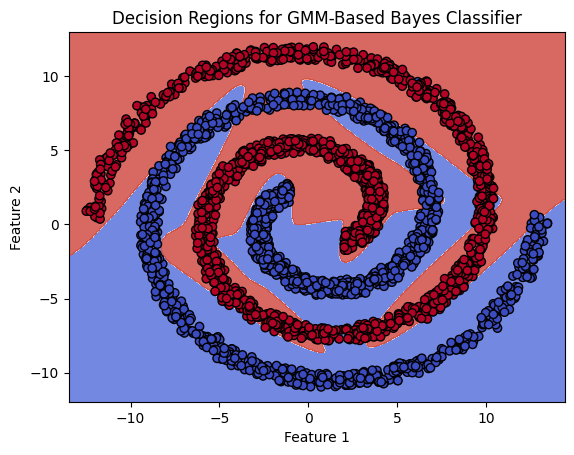

In [96]:
# Step 1: Generate grid of points
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

# Step 2: Compute log-likelihood for each class at grid points
grid_points = np.c_[xx.ravel(), yy.ravel()]
log_prob_class1 = gmm_log_likelihood(grid_points, means_class1, cov_class1, weights_class1)
log_prob_class2 = gmm_log_likelihood(grid_points, means_class2, cov_class2, weights_class2)

# Step 3: Assign each grid point to the class with the higher log-likelihood
Z = np.where(log_prob_class1 > log_prob_class2, 0, 1)

# Step 4: Reshape Z to the grid shape for plotting
Z = Z.reshape(xx.shape)

# Step 5: Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')

# Overlay the training data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap='coolwarm')

# Add labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions for GMM-Based Bayes Classifier')
plt.show()


In [102]:
def train_test_split_manual(X, y, test_size=0.3, random_state=None):
    if random_state:
        np.random.seed(random_state)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    split_idx = int(X.shape[0] * (1 - test_size))
    X_train, X_test = X[indices[:split_idx]], X[indices[split_idx:]]
    y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

    return X_train, X_test, y_train, y_test


In [103]:
# Manually split the dataset
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.3, random_state=42)

def bayes_classifier_manual(X_train, y_train, X_test, n_components_list):
    accuracies = []
    for n_components in n_components_list:
        print(f"\nTraining with {n_components} GMM components...")

        # Split data into Class 1 and Class 2
        X_class1 = X_train[y_train == 0]
        X_class2 = X_train[y_train == 1]

        # Train GMM for Class 1 and Class 2
        means_class1, cov_class1, weights_class1 = gmm_em(X_class1, n_components)
        means_class2, cov_class2, weights_class2 = gmm_em(X_class2, n_components)

        # Predict the class of the test samples
        log_prob_class1 = gmm_score_samples(X_test, means_class1, cov_class1, weights_class1)
        log_prob_class2 = gmm_score_samples(X_test, means_class2, cov_class2, weights_class2)

        # Apply Bayes' rule: classify based on which log-probability is higher
        y_pred = np.where(log_prob_class1 > log_prob_class2, 0, 1)

        # Compute the accuracy
        accuracy = accuracy_manual(y_test, y_pred)
        accuracies.append((n_components, accuracy))
        print(f"Accuracy with {n_components} components: {accuracy:.4f}")

    return accuracies

# List of different GMM components to experiment with
n_components_list = [1, 2, 4, 8, 16, 32, 64]

# Train and evaluate the GMM-based Bayes classifier
accuracies = bayes_classifier_manual(X_train, y_train, X_test, n_components_list)

# Plotting the results
n_components, accs = zip(*accuracies)
plt.plot(n_components, accs, marker='o')
plt.xlabel('Number of GMM Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of GMM Components')
plt.xscale('log')
plt.grid(True)
plt.show()



Training with 1 GMM components...
Convergence reached at iteration 1


ValueError: too many values to unpack (expected 3)